In [4]:
import pandas as pd
import numpy as np
data=pd.read_csv(r"C:\Users\Compu City\Desktop\studysec-new\back_end\study_data.csv")
data.head(10)

,subject,level,difficulty,importance,days_left,focus,hours_studied,delayed
0,Security,1,3,2,15,2,3.5,1
1,Security,5,4,1,2,1,2.1,1
2,Networking,5,2,5,27,2,2.0,1
3,Python,1,2,4,22,3,4.0,1
4,Database,1,1,4,7,3,2.7,1
5,Python,1,4,5,8,4,4.2,1
6,Python,5,3,5,13,1,2.6,1
7,Linux,3,1,2,56,1,2.0,1
8,Algorithms,3,2,3,23,2,2.1,1
9,Security,5,2,5,47,2,2.0,1


In [5]:
data['delayed'].value_counts()

delayed
1    797
0    203
Name: count, dtype: int64

In [6]:
print(data['delayed'].value_counts())

delayed
1    797
0    203
Name: count, dtype: int64


In [13]:
import random 
import numpy as np 
random.seed(42)
np.random.seed(42)
subjects = ["Networking", "Security", "ML", "Linux", "Python", "Database", "Web", "Algorithms"]
raws=[]
for _ in range(1000):
    subject=random.choice("subjects")
    level=random.randint(1,5)
    difficulty = random.randint(1, 5)
    importance = random.randint(1, 5)
    days_left = random.randint(1, 60)
    focus = random.randint(1, 5)
    hours_studied =round ( difficulity *0.4 +(6-level)*0.3 + focus * 0.3 +np.random.normal(0, 0.5) , 1)
    hours_studied= max(0.5, min(hours_studied, 6))
    prob_delay = (6 - focus) * 0.08 + (6 - level) * 0.05 + (days_left > 30) * 0.1
    delayed = 1 if random.random() < prob_delay else 0

    raws.append({
        "subject": subject,
        "level": level,
        "difficulty": difficulty,
        "importance": importance,
        "days_left": days_left,
        "focus": focus,
        "hours_studied": hours_studied,
        "delayed": delayed
    })

data = pd.DataFrame(raws)
data.to_csv("study_data.csv", index=False)
print(data['delayed'].value_counts())
    


delayed
0    561
1    439
Name: count, dtype: int64


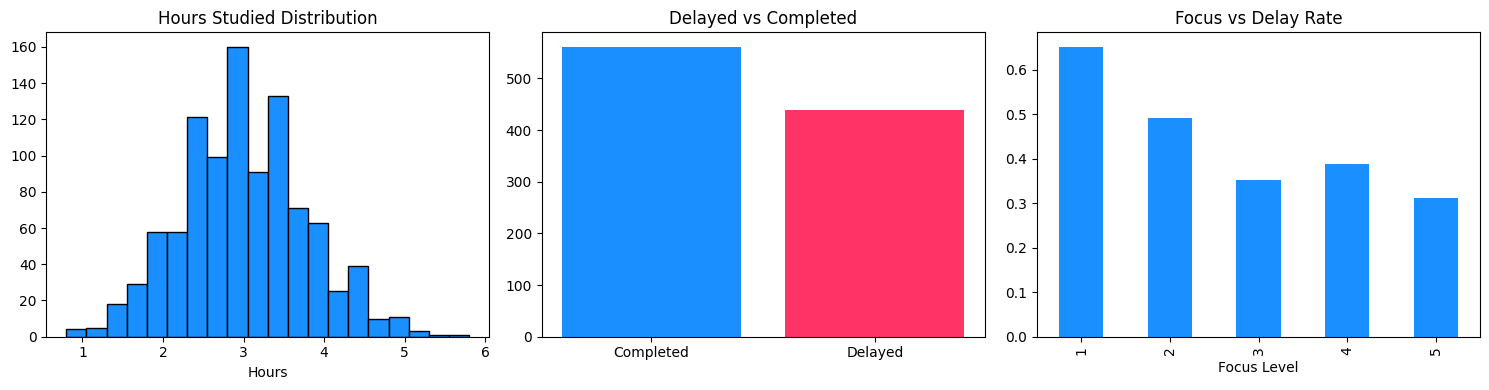

In [14]:
import matplotlib.pyplot as plt 
fig , axes = plt.subplots (1,3 , figsize =(15,4))
axes[0].hist(data['hours_studied'], bins=20, color='#1a8fff', edgecolor='black')
axes[0].set_title('Hours Studied Distribution')
axes[0].set_xlabel('Hours')

# 2 - delayed vs not delayed
axes[1].bar(['Completed', 'Delayed'], data['delayed'].value_counts(), color=['#1a8fff', '#ff3366'])
axes[1].set_title('Delayed vs Completed')

data.groupby('focus')['delayed'].mean().plot(kind='bar', ax=axes[2], color='#1a8fff')
axes[2].set_title('Focus vs Delay Rate')
axes[2].set_xlabel('Focus Level')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

features = ["level", "difficulty", "importance", "days_left", "focus"]
X = data[features]

# Model 1: Regression - توقع الساعات
y_hours = data["hours_studied"]
X_train, X_test, y_train, y_test = train_test_split(X, y_hours, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)
print(f"Regression MSE: {mean_squared_error(y_test, y_pred):.3f}")

# Model 2: Classification - توقع التأجيل
y_delayed = data["delayed"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_delayed, test_size=0.2, random_state=42)

clf_model = LogisticRegression()
clf_model.fit(X_train2, y_train2)
y_pred2 = clf_model.predict(X_test2)
print(f"Classification Accuracy: {accuracy_score(y_test2, y_pred2):.2%}")

Regression MSE: 0.241
Classification Accuracy: 67.50%


In [18]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# Classification
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest"      : RandomForestClassifier(random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "KNN"                : KNeighborsClassifier()
}

print("── Classification ──")
for name, model in classifiers.items():
    model.fit(X_train2, y_train2)
    acc = accuracy_score(y_test2, model.predict(X_test2))
    print(f"{name}: {acc:.2%}")

# Regression
regressors = {
    "Linear Regression": LinearRegression(),
    "Random Forest"    : RandomForestRegressor(random_state=42),
    "Decision Tree"    : DecisionTreeRegressor(random_state=42),
    "KNN"              : KNeighborsRegressor()
}

print("\n── Regression ──")
for name, model in regressors.items():
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"{name}: MSE = {mse:.3f}")

── Classification ──
Logistic Regression: 67.50%
Random Forest: 56.50%
Decision Tree: 59.00%
KNN: 59.00%

── Regression ──
Linear Regression: MSE = 0.241
Random Forest: MSE = 0.319
Decision Tree: MSE = 0.615
KNN: MSE = 0.358


In [20]:
import pickle

with open("regression_model.pkl", "wb") as f:
    pickle.dump(reg_model, f)

with open("classification_model.pkl", "wb") as f:
    pickle.dump(clf_model, f)

print(" Models saved!")

 Models saved!
